<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>



#### Import the required libraries we need for the lab.


In [9]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [18]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [11]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [12]:
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [22]:
boston_df.to_csv("boston_housing.csv", index=False)

In [14]:
boston_df.tail()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
501,501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,9.67,22.4
502,502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,9.08,20.6
503,503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,5.64,23.9
504,504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,6.48,22.0
505,505,0.04741,0.0,11.93,0.0,0.573,6.030,80.8,2.5050,1.0,273.0,21.0,7.88,11.9


## Creating a boxplot for MEDV

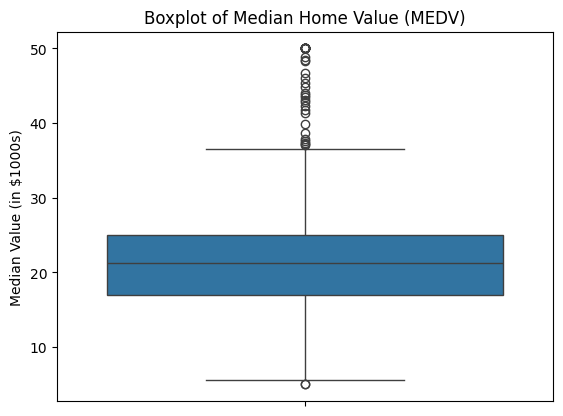

In [23]:
ax = sns.boxplot(y='MEDV', data=boston_df)
plt.title('Boxplot of Median Home Value (MEDV)')
plt.ylabel('Median Value (in $1000s)')
plt.show()

## Creating a bar plot for the Charles river variable

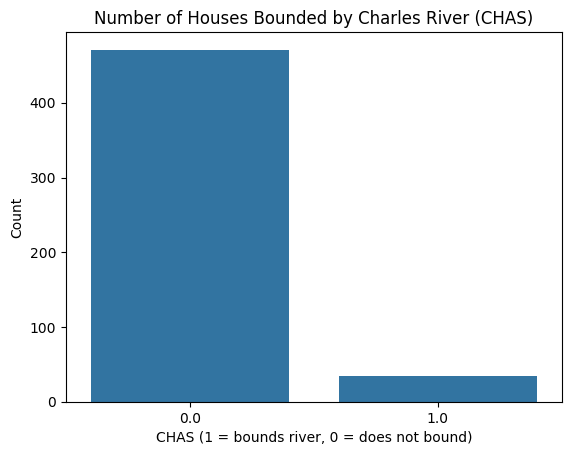

In [27]:
# Create a count plot (bar plot) for the 'CHAS' variable
sns.countplot(x='CHAS', data=boston_df)
plt.title('Number of Houses Bounded by Charles River (CHAS)')
plt.xlabel('CHAS (1 = bounds river, 0 = does not bound)')
plt.ylabel('Count')
plt.show()

## creating a boxplot for the MEDV variable vs the AGE variable. (Discretize the age variable into three groups of 35 years and younger, between 35 and 70 years and 70 years and older)

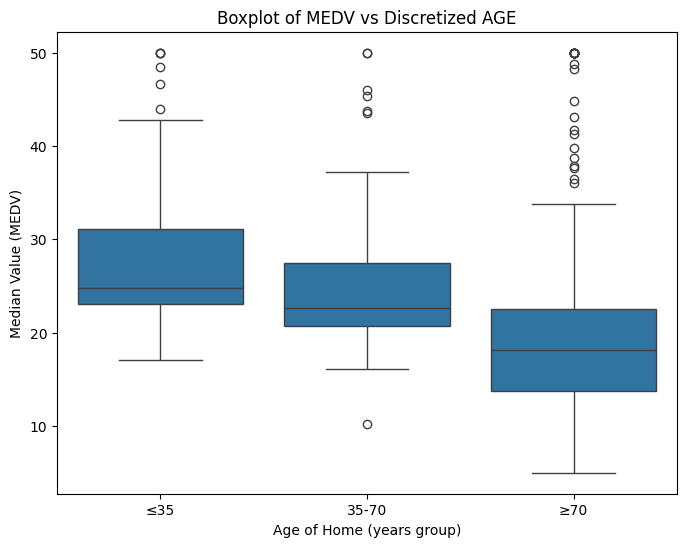

In [28]:
# Discretize AGE into three groups
bins = [0, 35, 70, 100]
labels = ['≤35', '35-70', '≥70']
boston_df['AGE_group'] = pd.cut(boston_df['AGE'], bins=bins, labels=labels, right=True)

# Create the boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x='AGE_group', y='MEDV', data=boston_df)
plt.xlabel('Age of Home (years group)')
plt.ylabel('Median Value (MEDV)')
plt.title('Boxplot of MEDV vs Discretized AGE')
plt.show()

## Creating a scatter plot to show the relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town. What can you say about the relationship?

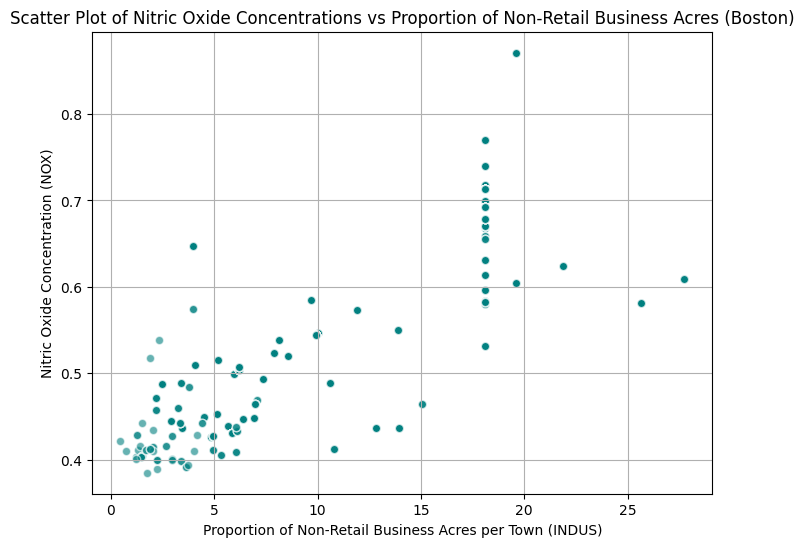

In [33]:
plt.figure(figsize=(8, 6))
plt.scatter(boston_df['INDUS'], boston_df['NOX'], alpha=0.6, edgecolors='w', color='teal')
plt.title('Scatter Plot of Nitric Oxide Concentrations vs Proportion of Non-Retail Business Acres (Boston)')
plt.xlabel('Proportion of Non-Retail Business Acres per Town (INDUS)')
plt.ylabel('Nitric Oxide Concentration (NOX)')
plt.grid(True)
plt.show()

## Creating a histogram for the pupil to teacher ratio variable

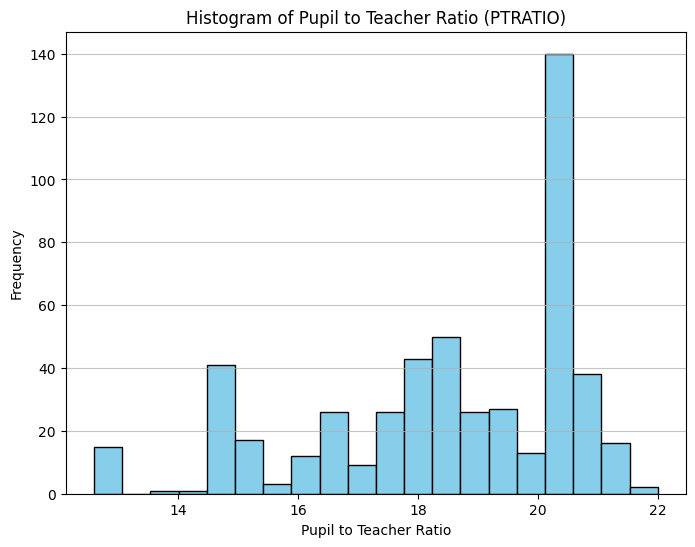

In [34]:
plt.figure(figsize=(8, 6))
plt.hist(boston_df['PTRATIO'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Pupil to Teacher Ratio (PTRATIO)')
plt.xlabel('Pupil to Teacher Ratio')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### T-Test: Using the boston housing data set, is there a significant difference in median value of houses bounded by the Charles river or not?

State the hypothesis

*   $H\_0: µ\_1 = µ\_2$ ("there is a difference in median value of houses bounded by the Charles river ")
*   $H\_1: µ\_1 ≠ µ\_2$ ("there is no difference in median value of houses bounded by the Charles river")

Use the <code>ttest_ind</code> from the <code>scipy_stats</code> library

In [36]:
scipy.stats.ttest_ind(boston_df[boston_df['CHAS'] == 1]['MEDV'],
                   boston_df[boston_df['CHAS'] == 0]['MEDV'], equal_var = True)

TtestResult(statistic=3.996437466090509, pvalue=7.390623170519905e-05, df=504.0)

**Conclusion:** Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that there is a significant difference in median value of houses bounded by the Charles river

### ANOVA: Using the teachers' rating data set,does the Median values of houses (MEDV) are differ for each proportion of owner occupied units built prior to 1940 (AGE)

### First, we group the data into three categories
*   Low Age: Proportion less than 33.3% (Most of the houses are built not in 1940's)
*   Medium Age: Proportion between 33.3% and 66.6% (Intermediate like the proportion is haif for both)
*   High Age: Proportion greater than 66.6% (Most of the houses are built in 1940's)

In [44]:
boston_df.loc[(boston_df['AGE'] <= 33), 'AGE_GROUP'] = 'Low_Age'
boston_df.loc[(boston_df['AGE'] > 33)&(boston_df['AGE'] < 66), 'AGE_GROUP'] = 'Medium_Age'
boston_df.loc[(boston_df['AGE'] >= 66), 'AGE_GROUP'] = 'High_Age'

State the hypothesis

*   $H\_0: µ\_1 = µ\_2 = µ\_3$ (the three Age group means are equal)
*   $H\_1:$ At least one of the means differ

In [56]:
scipy.stats.levene(boston_df[boston_df['AGE_GROUP'] == 'Low_Age']['MEDV'],
                   boston_df[boston_df['AGE_GROUP'] == 'Medium_Age']['MEDV'], 
                   boston_df[boston_df['AGE_GROUP'] == 'High_Age']['MEDV'], 
                   center='mean')

LeveneResult(statistic=1.8572446229456543, pvalue=0.15717104188317496)

First, separate the three samples (one for each job category) into a variable each.

In [58]:
Low_Age = boston_df[boston_df['AGE_GROUP'] == 'Low_Age']['MEDV']
Medium_Age = boston_df[boston_df['AGE_GROUP'] == 'Medium_Age']['MEDV']
High_Age = boston_df[boston_df['AGE_GROUP'] == 'High_Age']['MEDV']

Now, run a one-way ANOVA.

In [59]:
f_statistic, p_value = scipy.stats.f_oneway(Low_Age, Medium_Age, High_Age)
print("F_Statistic: {0}, P-Value: {1}".format(f_statistic,p_value))

F_Statistic: 32.2868064078215, P-Value: 6.423413089231037e-14


**Conclusion:** Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that there is no  significant difference in median value of houses for each proportion of owner occupied units built prior to 1940.

**Pearson Correlation:** The relationship between Nitric oxide concentrations and proportion of non-retail business acres per town

State the hypothesis:

*   $H\_0:$ The proportion of non-retail business acres per town is independent of Nitric oxide concentrations
*   $H\_1:$ The proportion of non-retail business acres per town is associated with Nitric oxide concentrations


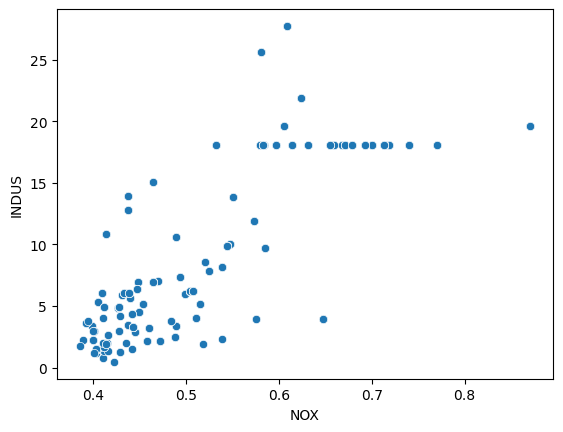

In [61]:
ax = sns.scatterplot(x="NOX", y="INDUS", data=boston_df)

In [64]:
scipy.stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])

PearsonRResult(statistic=0.7636514469209192, pvalue=7.913361061210442e-98)

**Conclusion:** Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that The proportion of non-retail business acres per town is associated with Nitric oxide concentrations.

**Regression analysis:** The impact of an additional weighted distance  to the five Boston employment centres on the median value of owner occupied homes

In [65]:
## insert code here
## create a list of students and evaluation socres
X = boston_df['DIS']
y = boston_df['MEDV']
## add an intercept (beta_0) to our model
X = sm.add_constant(X) 

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

# Print out the statistics
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Fri, 29 Aug 2025   Prob (F-statistic):           1.21e-08
Time:                        11:35:16   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.000      16.784      19.996
DIS            1.0916      0.188      5.795      0.000       0.722       1.462
==============================================================================
Omnibus:                      139.779   Durbin-Watson:                   0.570
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              305.104
Skew:                           1.466   Prob(JB):                     5.59e-67
Kurtosis:                       5.424   Cond. No.                         9.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Conclusion:** Since the coefficient of DIS is statistically significant (p < 0.05), it shows DIS is significantly correlated with MEDV.